In [2]:
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from mplsoccer import VerticalPitch
import time
from tqdm import tqdm
import seaborn as sns

from scipy.stats import norm, lognorm

import statsmodels.api as sm
import statsmodels.formula.api as smf


sys.path.append("../")
from xThreat import xThreat

In [3]:
# max_max_error = 0.014
max_max_error = 0.030714285714285715

# Import the data

In [4]:
# Load both old and new error dataframes
df_errors_old = pd.read_csv('../3-calculate-values/bootstrap_errors_normal_xthreat.csv').rename(columns={'sample_size': 'N'})
df_errors_new = pd.read_csv('../3-calculate-values/bootstrap_errors_normal_xthreat_rerun_extended.csv').rename(columns={'sample_size': 'N'})

# Append the new errors to the old errors
df_errors = pd.concat([df_errors_old, df_errors_new], ignore_index=True)

In [19]:
# Add additional columns
df_errors['M'] = df_errors['n_x'] * df_errors['n_y']
df_errors['1/sqrt(N)'] = 1/np.sqrt(df_errors['N'])
df_errors['Mlog(M)/sqrt(N)'] = df_errors['M']*np.log(df_errors['M'])*df_errors['1/sqrt(N)']
df_errors['M/sqrt(N)'] = df_errors['M']*df_errors['1/sqrt(N)']
df_errors['log(M)/sqrt(N)'] = np.log(df_errors['M'])*df_errors['1/sqrt(N)']
df_errors['M^{3/2}log(M)'] = (df_errors['M']**1.5)*np.log(df_errors['M'])
df_errors['M^{3/2}log(M)/sqrt(N)'] = df_errors['M^{3/2}log(M)']*df_errors['1/sqrt(N)']

In [20]:
# Make the norm a dimension independent norm
for col in df_errors.columns.tolist():
    if '1_norm' in col:
        df_errors[col] = df_errors[col]/df_errors['M']
    if ' 2_norm' in col:
        df_errors[col] = df_errors[col]/np.sqrt(df_errors['M'])

In [21]:
df_errors.head()

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,transition_matrix_resampled_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N),M/sqrt(N),log(M)/sqrt(N),M^(3/2)log(M),M^(3/2)log(M)/sqrt(N),M^{3/2}log(M),M^{3/2}log(M)/sqrt(N)
0,16,12,4000000,0,5176042,1.520996e-08,8.527680e-09,2.161103e-07,1.572373e-08,1.092219e-08,...,1.0,192,0.0005,0.50472,0.096,0.002629,13987.198625,6.993599,13987.198625,6.993599
1,16,12,4000000,1,5176043,9.162143e-09,4.508423e-09,1.841417e-07,9.331586e-09,1.087556e-08,...,1.0,192,0.0005,0.50472,0.096,0.002629,13987.198625,6.993599,13987.198625,6.993599
2,16,12,4000000,2,5176044,1.003033e-08,6.733231e-09,2.445171e-07,9.527752e-09,1.124043e-08,...,1.0,192,0.0005,0.50472,0.096,0.002629,13987.198625,6.993599,13987.198625,6.993599
3,16,12,4000000,3,5176045,1.640232e-08,9.482240e-09,1.516159e-07,1.165411e-08,1.187803e-08,...,1.0,192,0.0005,0.50472,0.096,0.002629,13987.198625,6.993599,13987.198625,6.993599
4,16,12,4000000,4,5176046,9.155078e-09,7.023638e-09,2.368550e-07,1.309245e-08,1.175562e-08,...,1.0,192,0.0005,0.50472,0.096,0.002629,13987.198625,6.993599,13987.198625,6.993599


In [22]:
df_errors.describe()

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,transition_matrix_resampled_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N),M/sqrt(N),log(M)/sqrt(N),M^(3/2)log(M),M^(3/2)log(M)/sqrt(N),M^{3/2}log(M),M^{3/2}log(M)/sqrt(N)
count,104000.000000,104000.000000,1.040000e+05,104000.000000,1.040000e+05,1.040000e+05,1.040000e+05,1.040000e+05,1.040000e+05,1.040000e+05,...,1.040000e+05,104000.000000,104000.000000,104000.000000,104000.000000,104000.000000,1.040000e+05,104000.000000,1.040000e+05,104000.000000
mean,28.615385,21.538462,8.675000e+05,499.500000,2.974503e+06,5.745531e-08,2.914176e-08,1.431613e-06,5.927406e-08,8.563767e-08,...,1.000000e+00,847.846154,0.001835,11.341260,1.556148,0.011063,2.640548e+05,484.649761,2.640548e+05,484.649761
std,17.617988,13.141983,1.240810e+06,288.676378,1.791256e+06,1.234325e-07,5.653855e-08,3.056378e-06,1.154005e-07,1.922773e-07,...,2.235204e-16,934.112527,0.000873,16.215806,2.037898,0.005878,4.069730e+05,858.737253,4.069730e+05,858.737253
min,8.000000,6.000000,1.000000e+05,0.000000,6.880420e+05,1.221565e-10,8.203798e-11,4.452843e-10,1.666483e-10,3.110156e-11,...,1.000000e+00,48.000000,0.000500,0.092909,0.024000,0.001936,1.287382e+03,0.643691,1.287382e+03,0.643691
25%,14.000000,11.000000,1.600000e+05,249.750000,1.489292e+06,1.746640e-09,1.219219e-09,8.437488e-09,2.236289e-09,6.724227e-10,...,1.000000e+00,154.000000,0.001164,1.089480,0.221524,0.006314,9.626068e+03,12.625974,9.626068e+03,12.625974
50%,24.000000,18.000000,3.050000e+05,499.500000,2.464542e+06,9.515810e-09,6.212620e-09,9.125551e-08,1.166514e-08,7.637741e-09,...,1.000000e+00,432.000000,0.001843,4.202079,0.642976,0.010556,5.448810e+04,80.971587,5.448810e+04,80.971587
75%,40.000000,30.000000,7.975000e+05,749.250000,4.256791e+06,5.426257e-08,3.054050e-08,1.081006e-06,6.123464e-08,6.535656e-08,...,1.000000e+00,1200.000000,0.002512,14.028312,1.995301,0.015279,2.947290e+05,473.371116,2.947290e+05,473.371116
max,64.000000,48.000000,4.000000e+06,999.000000,8.705041e+06,1.982320e-06,8.297645e-07,2.931567e-05,1.272217e-06,1.538907e-06,...,1.000000e+00,3072.000000,0.003162,78.008388,9.714517,0.025393,1.367263e+06,4323.663738,1.367263e+06,4323.663738


In [23]:
print("Possible values of n_x", df_errors['n_x'].unique().tolist())
print("Possible values of n_y", df_errors['n_y'].unique().tolist())
print("Possible values of N", df_errors['N'].unique().tolist())
print("Possible values of M", df_errors['M'].unique().tolist())

Possible values of n_x [16, 32, 40, 48, 56, 64, 8, 10, 12, 14, 20, 24, 28]
Possible values of n_y [12, 24, 30, 36, 42, 48, 6, 8, 9, 11, 15, 18, 21]
Possible values of N [4000000, 1300000, 630000, 370000, 240000, 170000, 130000, 100000]
Possible values of M [192, 768, 1200, 1728, 2352, 3072, 48, 80, 108, 154, 300, 432, 588]


# General result inspection

[(np.float64(0.267004), np.float64(0.004874), np.float64(0.329415), np.float64(1.0)), (np.float64(0.275191), np.float64(0.194905), np.float64(0.496005), np.float64(1.0)), (np.float64(0.212395), np.float64(0.359683), np.float64(0.55171), np.float64(1.0)), (np.float64(0.151918), np.float64(0.500685), np.float64(0.557587), np.float64(1.0)), (np.float64(0.12478), np.float64(0.640461), np.float64(0.527068), np.float64(1.0)), (np.float64(0.311925), np.float64(0.767822), np.float64(0.415586), np.float64(1.0)), (np.float64(0.616293), np.float64(0.852709), np.float64(0.230052), np.float64(1.0)), (np.float64(0.993248), np.float64(0.906157), np.float64(0.143936), np.float64(1.0))]


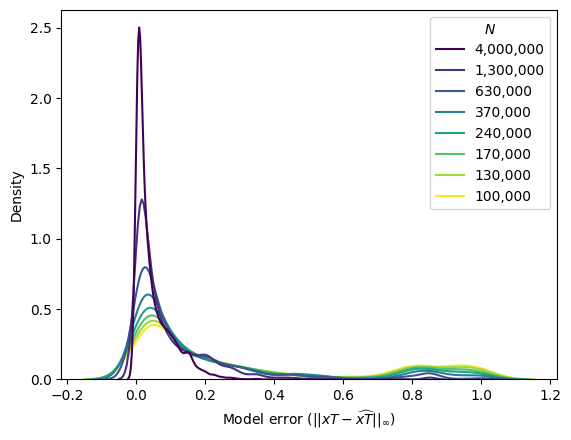

In [28]:
cmap = 'viridis'

ax = sns.kdeplot(data=df_errors, x='xT_error_inf_norm', hue='1/sqrt(N)', palette=cmap)

# Get the unique hue values ('1/sqrt(N)')
hue_levels = np.unique(df_errors['1/sqrt(N)'])
rounded_hue_levels = [f"{int(1/level**2):,}" for level in hue_levels]

# Create a color palette based on the hue values
cmap = matplotlib.colormaps[cmap]
palette = [cmap( (hue_level-hue_levels.min())/(hue_levels.max()-hue_levels.min()) ) for hue_level in hue_levels]
print(cmap)
# Create custom legend handles: we need to map each color to the corresponding hue value
handles = [matplotlib.lines.Line2D([0], [0], color=palette[i]) for i in range(len(hue_levels))]

# Set the legend with the correct rounded labels
ax.legend(handles, rounded_hue_levels, title=r"$N$")
print(palette)
# Set the x-axis label
ax.set_xlabel(r"Model error ($||xT-\widehat{xT}||_\infty$)")

plt.show()

[(np.float64(0.267004), np.float64(0.004874), np.float64(0.329415), np.float64(1.0)), (np.float64(0.279574), np.float64(0.170599), np.float64(0.479997), np.float64(1.0)), (np.float64(0.257322), np.float64(0.25613), np.float64(0.526563), np.float64(1.0)), (np.float64(0.21621), np.float64(0.351535), np.float64(0.550627), np.float64(1.0)), (np.float64(0.190631), np.float64(0.407061), np.float64(0.556089), np.float64(1.0)), (np.float64(0.149039), np.float64(0.508051), np.float64(0.55725), np.float64(1.0)), (np.float64(0.121148), np.float64(0.592739), np.float64(0.544641), np.float64(1.0)), (np.float64(0.137339), np.float64(0.662252), np.float64(0.515571), np.float64(1.0)), (np.float64(0.20803), np.float64(0.718701), np.float64(0.472873), np.float64(1.0)), (np.float64(0.421908), np.float64(0.805774), np.float64(0.35191), np.float64(1.0)), (np.float64(0.636902), np.float64(0.856542), np.float64(0.21662), np.float64(1.0)), (np.float64(0.83527), np.float64(0.886029), np.float64(0.102646), np.f

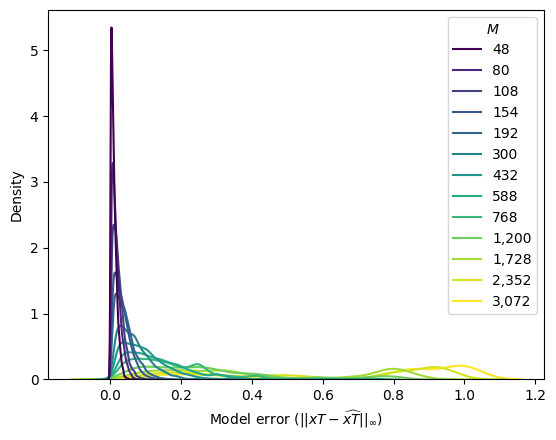

In [31]:
cmap = 'viridis'


ax = sns.kdeplot(data=df_errors, x='xT_error_inf_norm', hue=np.log(df_errors['M']), palette=cmap)

# Get the unique hue values ('M')
hue_levels = np.unique(np.log(df_errors['M']))
labels = [f"{int(level):,}" for level in np.unique(df_errors['M'])]

# Create a color palette based on the hue values
cmap = matplotlib.colormaps[cmap]
palette = [cmap( (hue_level-hue_levels.min())/(hue_levels.max()-hue_levels.min()) ) for hue_level in hue_levels]
print(cmap)
# Create custom legend handles: we need to map each color to the corresponding hue value
handles = [matplotlib.lines.Line2D([0], [0], color=palette[i]) for i in range(len(hue_levels))]

# Set the legend with the correct rounded labels
ax.legend(handles, labels, title=r"$M$")
print(palette)
# Set the x-axis label
ax.set_xlabel(r"Model error ($||xT-\widehat{xT}||_\infty$)")

plt.show()

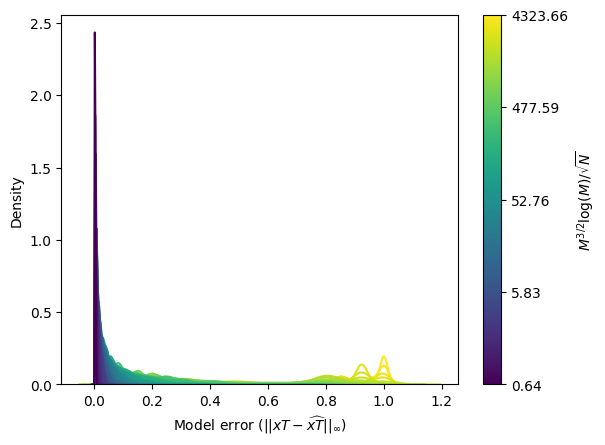

In [38]:
fig, ax = plt.subplots()
norm = plt.Normalize(np.log(df_errors['M^{3/2}log(M)/sqrt(N)'].min()), np.log(df_errors['M^{3/2}log(M)/sqrt(N)'].max()))
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])

sns.kdeplot(
    data=df_errors, 
    x='xT_error_inf_norm', 
    hue=np.log(df_errors['M^{3/2}log(M)/sqrt(N)']), 
    palette='viridis',
    hue_norm=norm,
    ax=ax
)

# Remove the legend
ax.get_legend().remove()
ax.set_xlabel(r"Model error ($||xT-\widehat{xT}||_\infty$)")

# Add a color bar with the correct ticks of 'M^{3/2}log(M)/sqrt(N)'
min_val = np.min(np.log(np.unique(df_errors['M^{3/2}log(M)/sqrt(N)'])))
max_val = np.max(np.log(np.unique(df_errors['M^{3/2}log(M)/sqrt(N)'])))
ticks_positions = np.linspace(min_val, max_val, num=5)
ticks_values = np.exp(ticks_positions)
# ticks_position = np.log(np.unique(df_errors['M^{3/2}log(M)/sqrt(N)']))
# ticks_values = np.unique(df_errors['M^{3/2}log(M)/sqrt(N)'])

# Add a color bar with the correct ticks at the correct places
cbar = plt.colorbar(sm, ax=ax, ticks=ticks_positions)
cbar.set_ticklabels([f"{val:.2f}" for val in ticks_values])
cbar.set_label(r"$M^{3/2}\log(M)/\sqrt{N}$")

plt.show()

# Subparts of Model

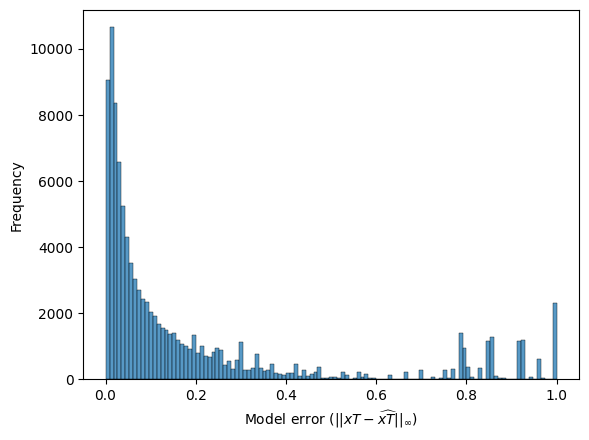

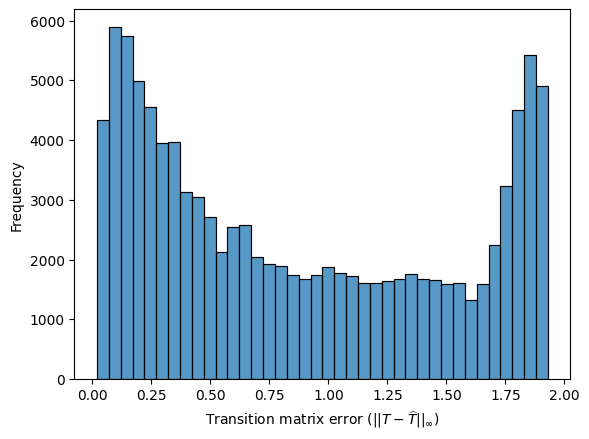

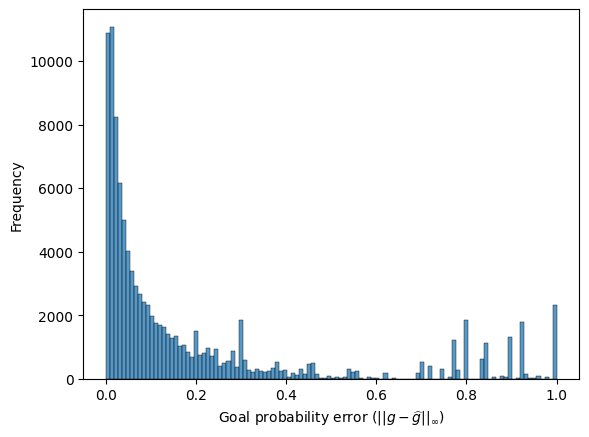

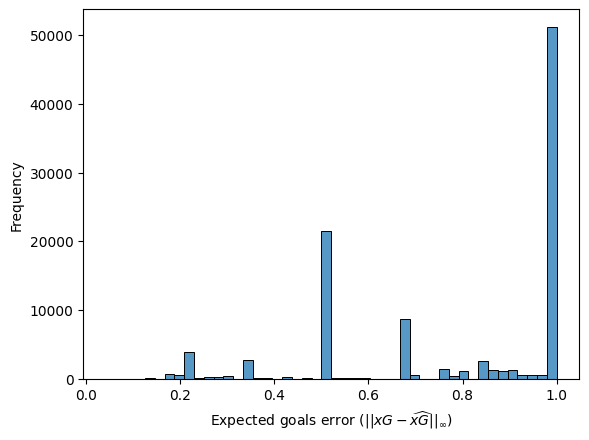

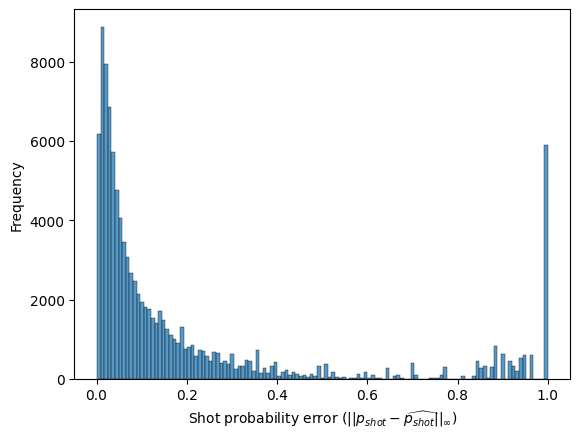

In [41]:
# Plot histograms of the errors
error_columns = ['xT_error_inf_norm', 'transition_matrix_error_inf_norm', 
                 'g_error_inf_norm', 'xG_error_inf_norm', 'prob_shot_error_inf_norm']
error_labels = [r'Model error ($||xT-\widehat{xT}||_\infty$)', 
                r'Transition matrix error ($||T-\widehat{T}||_\infty$)', 
                r'Goal probability error ($||g-\widehat{g}||_\infty$)', 
                r'Expected goals error ($||xG-\widehat{xG}||_\infty$)', 
                r'Shot probability error ($||p_{shot}-\widehat{p_{shot}}||_\infty$)']

for error_col, error_label in zip(error_columns, error_labels):
    plt.figure()
    sns.histplot(df_errors[error_col], bins='auto', kde=False)
    # plt.title(f"Histogram of {error_label}")
    plt.xlabel(error_label)
    plt.ylabel("Frequency")
    plt.show()

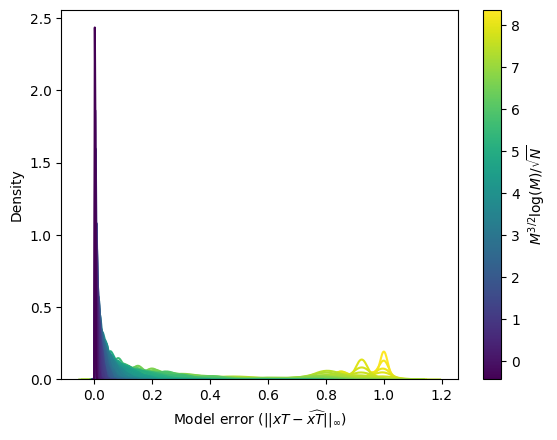

In [ ]:
# Scatterplot of the errors vs the model error with histogram of the errors



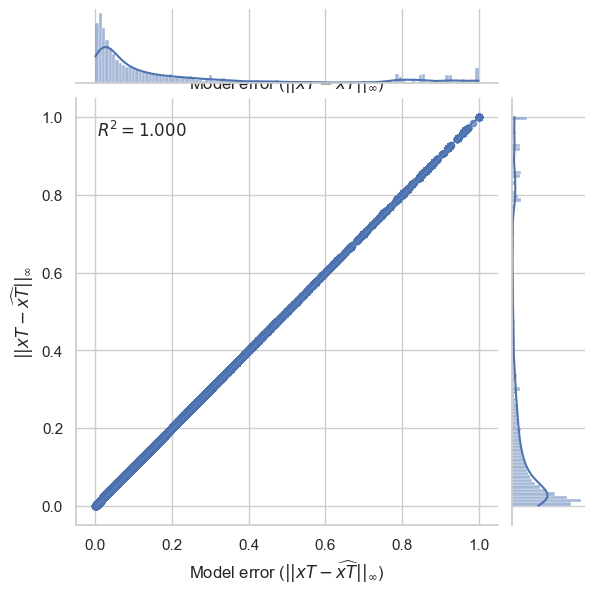

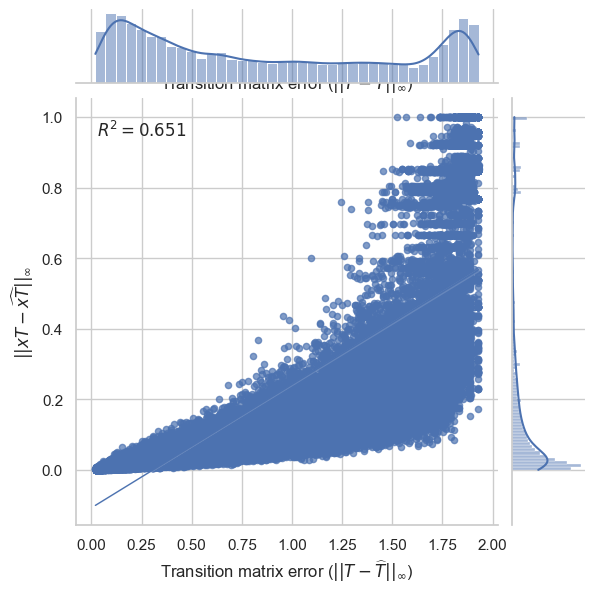

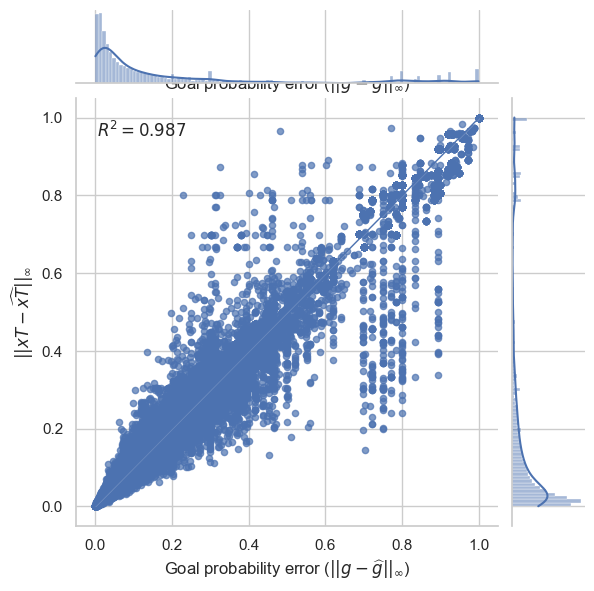

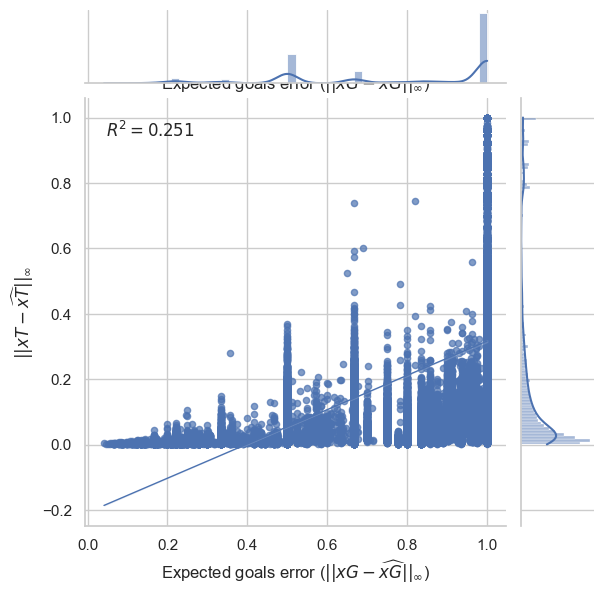

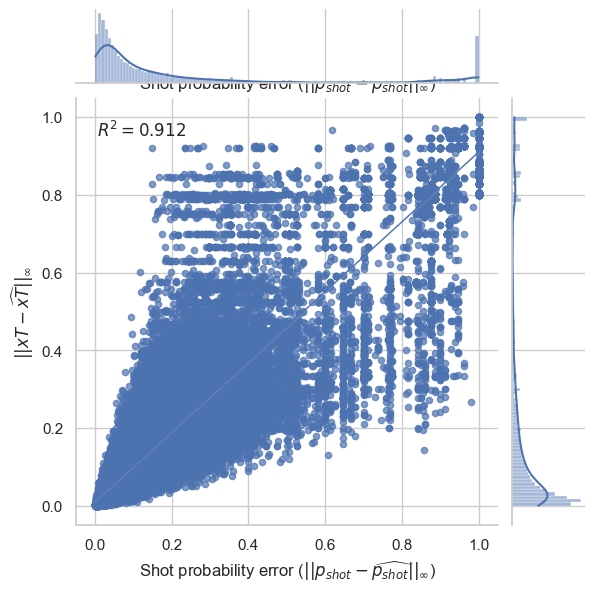

In [ ]:
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

for col, label in zip(error_columns, error_labels):

    x = df_errors[col].values
    y = df_errors['xT_error_inf_norm'].values

    # Compute R^2
    coeffs = np.polyfit(x, y, 1)
    y_pred = np.polyval(coeffs, x)
    r2 = r2_score(y, y_pred)

    # Create jointplot with regression
    g = sns.jointplot(
        data=df_errors,
        x=col,
        y='xT_error_inf_norm',
        kind="reg",        # scatter + regression line
        height=6,
        scatter_kws=dict(s=20, alpha=0.7),
        line_kws=dict(linewidth=1)
    )

    # Add R^2 annotation
    g.ax_joint.text(
        0.05, 0.95,
        f"$R^2 = {r2:.3f}$",
        transform=g.ax_joint.transAxes,
        ha='left', va='top'
    )

    # Title formatting
    # g.ax_joint.set_title(label)
    g.ax_joint.set_ylabel(r'$||xT-\widehat{xT}||_\infty$')
    g.ax_joint.set_xlabel(label)

    plt.show()


In [ ]:
# Define the plot
g = sns.PairGrid(df_errors[['xT_error_inf_norm', 'transition_matrix_error_inf_norm', 
                            'g_error_inf_norm', 'xG_error_inf_norm', 'prob_shot_error_inf_norm']])

# Map different plots to different sections of the grid
def corrfunc(x, y, **kwargs):
    r = np.corrcoef(x, y)[0, 1]
    ax = plt.gca()
    ax.annotate(f'r = {r:.2f}', xy=(0.5, 0.5), xycoords=ax.transAxes, 
                ha="center", va="center", fontsize=12, fontweight="bold")

g.map_upper(corrfunc)
g.map_lower(sns.kdeplot, fill=True)
g.map_diag(sns.histplot)

# Rename axis labels
new_labels = {
    'xT_error_inf_norm': 'Maximal xT Error',
    'transition_matrix_error_inf_norm': 'Maximal Transition Matrix Error',
    'g_error_inf_norm': 'Maximal g Error',
    'xG_error_inf_norm': 'Maximal xG Error',
    'prob_shot_error_inf_norm': 'Maximal Probability Shot Error'
}

# Update axis labels
for ax in g.axes.flatten():
    if ax is not None:  # Some may be empty
        xlabel = ax.get_xlabel()
        ylabel = ax.get_ylabel()
        if xlabel in new_labels:
            ax.set_xlabel(new_labels[xlabel])
        if ylabel in new_labels:
            ax.set_ylabel(new_labels[ylabel])

plt.show()

# OLS Modeling

In [153]:
df_errors_ols = df_errors[df_errors['Mlog(M)/sqrt(N)'] < 15].copy()
df_errors_ols['sqrt(M)log(M)/sqrt(N)'] = df_errors_ols['log(M)/sqrt(N)'] * np.sqrt(df_errors_ols['M'])

                            OLS Regression Results                            
Dep. Variable:      xT_error_inf_norm   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.870
Method:                 Least Squares   F-statistic:                 2.651e+05
Date:                 do, 08 jan 2026   Prob (F-statistic):               0.00
Time:                        16:49:10   Log-Likelihood:                -43294.
No. Observations:               79000   AIC:                         8.659e+04
Df Residuals:                   78997   BIC:                         8.662e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.0550      0.016   -125.

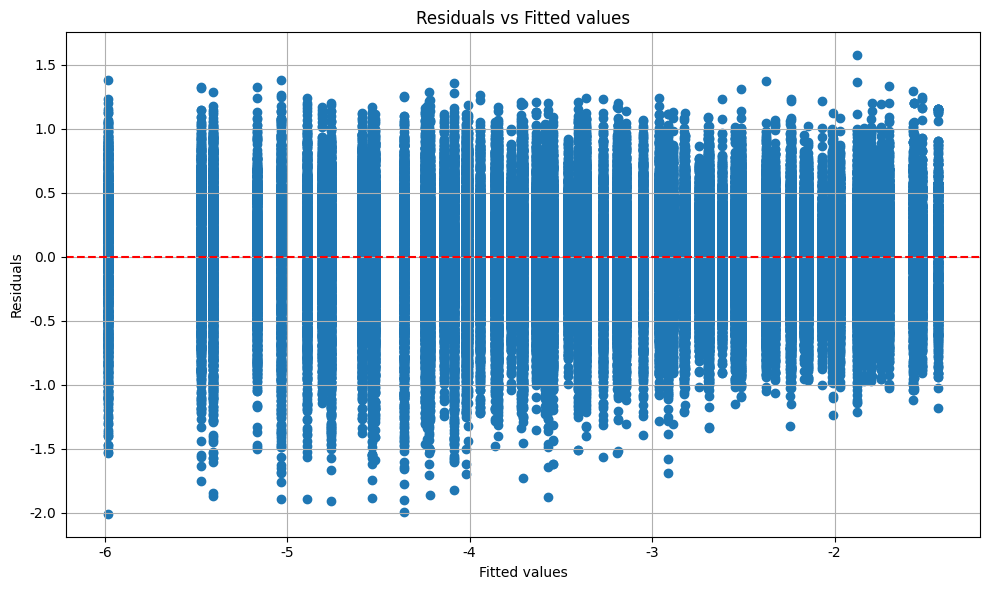

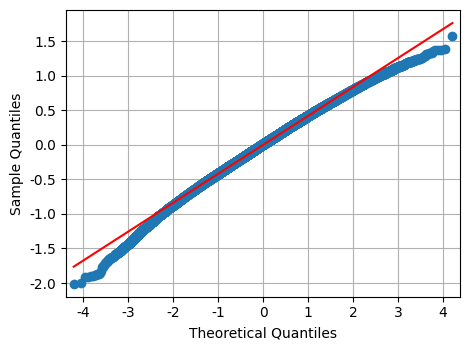

In [ ]:
# Do OLS regression on log transformations

X = sm.add_constant(pd.DataFrame({
    'log(M)': np.log(df_errors_ols['M']),
    'log(1/sqrt(N))': -np.log(np.sqrt(df_errors_ols['N']))
    }))
Y = np.log(df_errors_ols['xT_error_inf_norm'])
# Fit the model
model = sm.OLS(Y,X)
results = model.fit()
print(results.summary())

# Plot the residuals and values
plt.figure(figsize=(10, 6))
plt.scatter(results.fittedvalues, results.resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted values')
plt.grid(True)
plt.tight_layout()
plt.show()


# Plot the QQ plot of the residuals
# fig, ax = plt.subplots(figsize=(6.4, 4.8))
fig, ax = plt.subplots(figsize=(4.8, 3.6))
# fig, ax = plt.subplots(figsize=(3.2, 2.4))
sm.qqplot(results.resid, line='s', ax = ax)
# plt.title('QQ plot of residuals')
plt.grid(True)
plt.tight_layout()
plt.show()


In [161]:
c = results.params['const']
power = results.params['log(M)']
std_residuals = np.sqrt(results.mse_resid)
beta = results.params['log(1/sqrt(N))']
print(f"c={c}")
print(f"power={power}")
print(f"std_residuals={std_residuals}")
print(f"beta={beta}")

c=-2.0549618693866707
power=1.006356015220525
std_residuals=0.41857836237825136
beta=1.0294922965295545


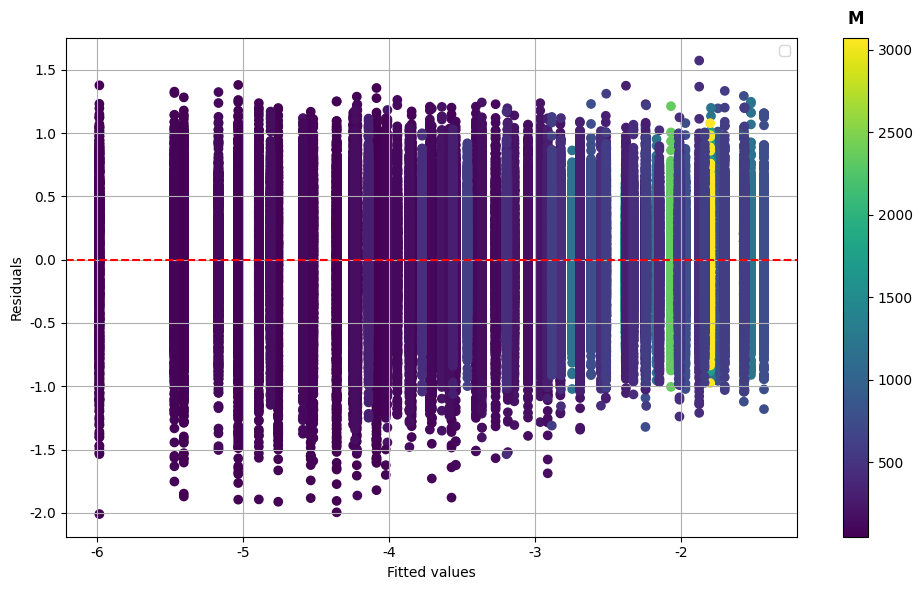

[6.4 4.8]


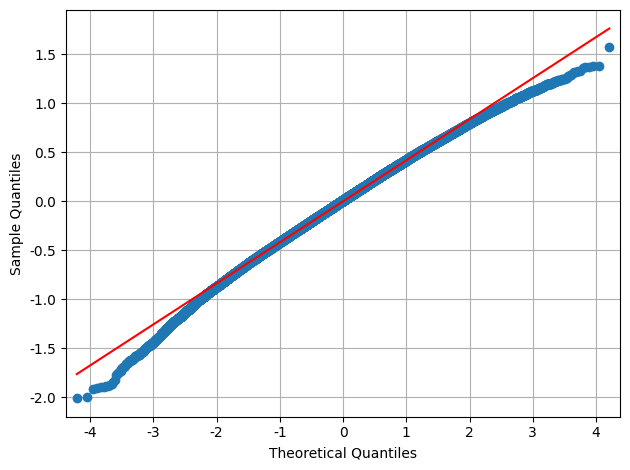

In [166]:
# Plot the residuals and values
plt.figure(figsize=(10, 6))
plt.scatter(results.fittedvalues, results.resid, c=df_errors_ols['M'], cmap='viridis')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')

# plt.title('Residuals vs Fitted values')

cbar = plt.colorbar()
cbar.ax.set_title('M', weight='bold', pad=10)
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

# Plot the QQ plot of the residuals
fig = sm.qqplot(results.resid, line='s')
print(fig.get_size_inches())
# plt.title('QQ plot of residuals')
plt.grid(True)
plt.tight_layout()
plt.show()

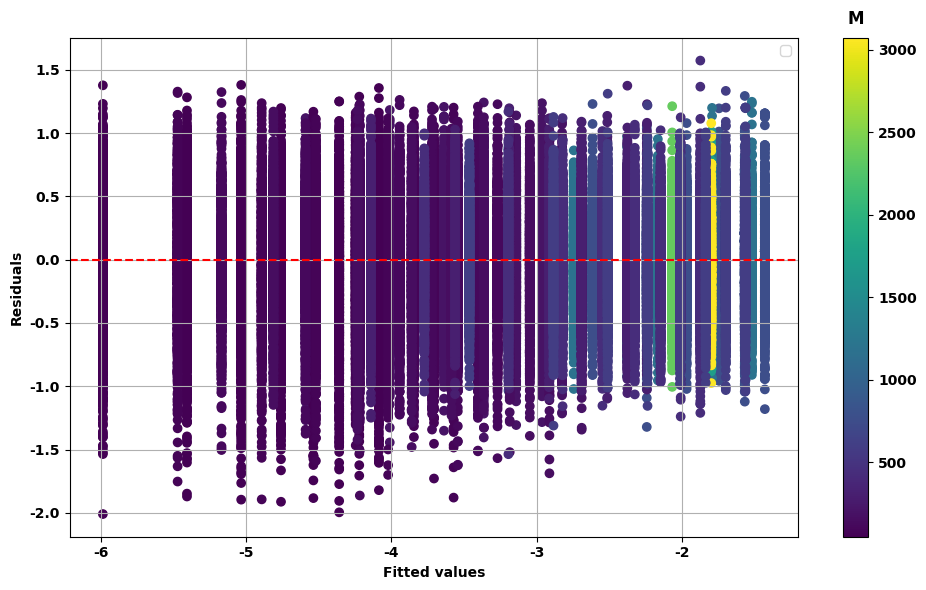

[6.4 4.8]


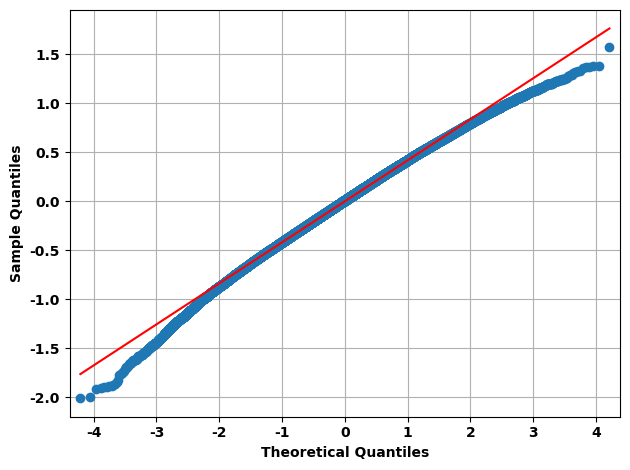

In [167]:
# Plot the residuals and values
plt.figure(figsize=(10, 6))
plt.scatter(results.fittedvalues, results.resid, c=df_errors_ols['M'], cmap='viridis')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values', weight='bold')
plt.ylabel('Residuals', weight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
# plt.title('Residuals vs Fitted values')

cbar = plt.colorbar()
cbar.ax.set_title('M', weight='bold', pad=10)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

# Plot the QQ plot of the residuals
fig = sm.qqplot(results.resid, line='s')
# Make axes label bold
fig.axes[0].set_xlabel('Theoretical Quantiles', weight='bold')
fig.axes[0].set_ylabel('Sample Quantiles', weight='bold')
print(fig.get_size_inches())
# plt.title('QQ plot of residuals')
plt.grid(True)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.tight_layout()
plt.show()

<Axes: xlabel='None', ylabel='xT_error_inf_norm'>

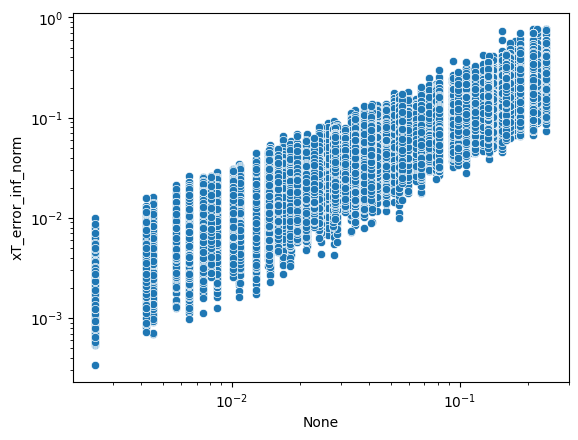

In [168]:
fig, ax =  plt.subplots(figsize=(6.4, 4.8))
ax.set(xscale='log', yscale='log')
sns.scatterplot(
    x=np.exp(results.fittedvalues),
    y=df_errors_ols['xT_error_inf_norm'],
    ax=ax,
)

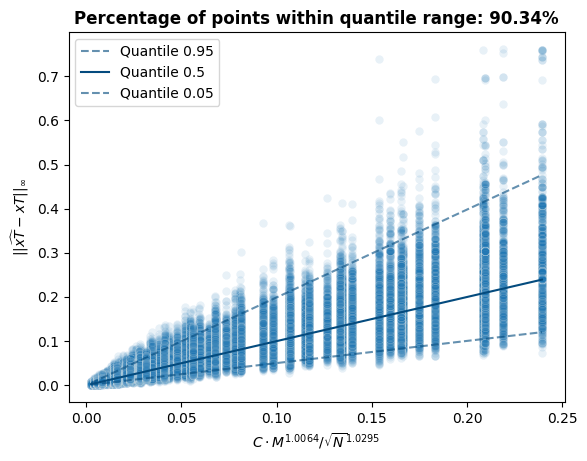

In [169]:
fig, ax = plt.subplots(figsize=(6.4, 4.8))

xs = np.exp(c)*df_errors_ols['M']**power * df_errors_ols['1/sqrt(N)']**beta

sns.scatterplot(
    x=xs,
    y=df_errors_ols['xT_error_inf_norm'],
    ax=ax,
    alpha=0.1,
)

# Add quantiles
quantiles = [0.05, 0.5, 0.95]
linestyles = ['--', '-', '--']
colors = ['blue', 'darkblue', 'blue']
colors = ["#044b7e9d", "#044b7e", '#044b7e9d']


xs_plot = np.linspace(xs.min(), xs.max(), 1000)
for i, q in enumerate(quantiles[::-1]):
    quantile = lognorm.ppf(q, s=std_residuals, scale=xs_plot)
    plt.plot(xs_plot, quantile, label=f'Quantile {q}', linestyle=linestyles[i], color=colors[i])

ax.set_xlabel(r'$C\cdot M^{%.4f} / \sqrt{N}^{%.4f}$' % (power, beta), weight='bold')
ax.set_ylabel(r'$||\widehat{xT} - xT||_{\infty}$', weight='bold')

# Calculate the number of points within the quantile range
within_quantile = df_errors_ols[
    (df_errors_ols['xT_error_inf_norm'] >= lognorm.ppf(0.05, s=std_residuals, scale=xs)) &
    (df_errors_ols['xT_error_inf_norm'] <= lognorm.ppf(0.95, s=std_residuals, scale=xs))
]

within_quantile_count = len(within_quantile)
plt.title(f'Percentage of points within quantile range: {within_quantile_count/len(xs)*100:.2f}%', weight='bold')
# Make it an annotation
# plt.annotate(
#     f'Percentage of points within quantile range: {within_quantile_count/len(xs)*100:.2f}%',
#     xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, ha='left', va='top',
#     bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='white')
# )

plt.legend()

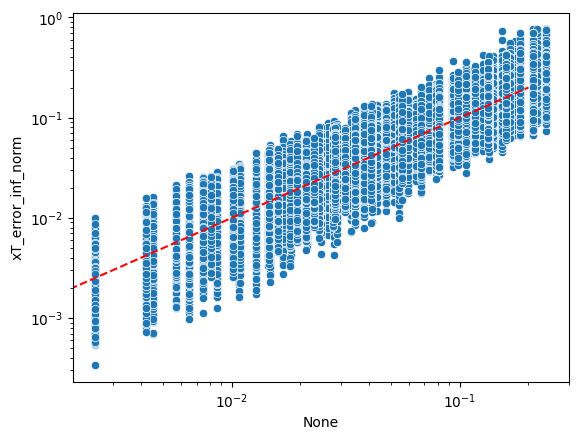

In [170]:
fig, ax =  plt.subplots(figsize=(6.4, 4.8))
ax.set(xscale='log', yscale='log')
sns.scatterplot(
    x=np.exp(results.fittedvalues),
    y=df_errors_ols['xT_error_inf_norm'],
    ax=ax,
)
# Add line y=x
plt.plot([0, 0.2], [0, 0.2], color='red', linestyle='--', label='y=x')